In [14]:
import pickle

# 读取 .pkl 文件
with open('results.pkl', 'rb') as f:  # 必须用二进制模式 'rb'
    result_dict = pickle.load(f)

In [15]:
import numpy as np
from scipy import stats
import pandas as pd

# Calculate average RMSE and MAE for each model
model_metrics = {}

for model_type in result_dict:
    for task_type in result_dict[model_type]:
        for model_name in result_dict[model_type][task_type]:
            rmses = []
            maes = []
            for idx in result_dict[model_type][task_type][model_name]:
                rmses.append(result_dict[model_type][task_type][model_name][idx]['RMSE'])
                maes.append(result_dict[model_type][task_type][model_name][idx]['MAE'])
            
            full_name = f"{model_type}_{task_type}_{model_name}"
            model_metrics[full_name] = {
                'mean_RMSE': np.mean(rmses),
                'mean_MAE': np.mean(maes),
                'all_RMSE': rmses,
                'all_MAE': maes
            }

# Create DataFrame for average performance
avg_perf_data = []
for model in model_metrics:
    avg_perf_data.append({
        'Model': model,
        'Avg RMSE': model_metrics[model]['mean_RMSE'],
        'Avg MAE': model_metrics[model]['mean_MAE']
    })
    
avg_perf_df = pd.DataFrame(avg_perf_data).sort_values('Avg RMSE')
print("\nAverage Performance Across All Models:")
print(avg_perf_df.to_string(index=False))

# Get all model names
models = list(model_metrics.keys())
n_models = len(models)

# Initialize comparison results storage
pairwise_data = []

# Perform pairwise comparisons
for i in range(n_models):
    for j in range(i+1, n_models):
        model1 = models[i]
        model2 = models[j]
        
        # RMSE comparison
        rmse1 = model_metrics[model1]['all_RMSE']
        rmse2 = model_metrics[model2]['all_RMSE']
        
        # MAE comparison
        mae1 = model_metrics[model1]['all_MAE']
        mae2 = model_metrics[model2]['all_MAE']
        
        # Calculate win/loss counts
        rmse_better = sum(r1 < r2 for r1, r2 in zip(rmse1, rmse2))
        rmse_worse = sum(r1 > r2 for r1, r2 in zip(rmse1, rmse2))
        
        mae_better = sum(m1 < m2 for m1, m2 in zip(mae1, mae2))
        mae_worse = sum(m1 > m2 for m1, m2 in zip(mae1, mae2))
        
        # One-sided t-tests
        rmse_t, rmse_p = stats.ttest_rel(rmse1, rmse2, alternative='less')
        mae_t, mae_p = stats.ttest_rel(mae1, mae2, alternative='less')
        
        pairwise_data.append({
            'Model 1': model1,
            'Model 2': model2,
            'RMSE: Model 1 Better': rmse_better,
            'RMSE: Model 1 Worse': rmse_worse,
            'RMSE p-value': rmse_p,
            'RMSE Significant': rmse_p < 0.05,
            'MAE: Model 1 Better': mae_better,
            'MAE: Model 1 Worse': mae_worse,
            'MAE p-value': mae_p,
            'MAE Significant': mae_p < 0.05
        })

# Create pairwise comparison DataFrame
pairwise_df = pd.DataFrame(pairwise_data)

# Display significant results
significant_results = pairwise_df[
    (pairwise_df['RMSE Significant']) | 
    (pairwise_df['MAE Significant'])
].sort_values(['RMSE p-value', 'MAE p-value'])

print("\nPairwise Model Comparisons (Significant Differences Only):")
print(significant_results.to_string(index=False))

# Optional: Save results to CSV
# avg_perf_df.to_csv('model_average_performance.csv', index=False)
# pairwise_df.to_csv('model_pairwise_comparisons.csv', index=False)
# significant_results.to_csv('significant_differences.csv', index=False)


Average Performance Across All Models:
                                                                    Model  Avg RMSE  Avg MAE
                      FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10  0.311532 0.213168
                      FNO2d_recurrent_modes16_width60_epochs500_Tin10_T10  0.315702 0.216745
                      FNO2d_recurrent_modes48_width60_epochs500_Tin10_T10  0.325217 0.223623
                      FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10  0.335240 0.234046
                      FNO2d_recurrent_modes64_width40_epochs500_Tin10_T10  0.337644 0.235757
                      FNO2d_recurrent_modes32_width60_epochs500_Tin10_T10  0.340296 0.230033
                      FNO2d_recurrent_modes96_width40_epochs500_Tin10_T10  0.341112 0.237695
                      FNO2d_recurrent_modes48_width40_epochs500_Tin10_T10  0.343496 0.239848
                     FNO2d_recurrent_modes128_width40_epochs500_Tin10_T10  0.352749 0.244336
                      FNO2d_re

In [3]:
pd.set_option('display.max_colwidth', None)  # Show full column content
pd.set_option('display.width', None)        # Auto-detect terminal width
pd.set_option('display.max_columns', None)  # Show all columns

In [12]:
avg_perf_df

,Model,Avg RMSE,Avg MAE
5,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,0.311532,0.213168
3,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,0.335240,0.234046
8,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,0.505344,0.347536
9,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,0.527340,0.365085
6,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,0.532029,0.371948
4,FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,0.548878,0.376137
2,FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,0.549336,0.387712
10,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,0.764626,0.544359
7,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,0.807495,0.580186
1,FNO2d_initial_to_final_modes64_width60_epochs500,0.825590,0.591958


In [13]:
pairwise_df

,Model 1,Model 2,RMSE: Model 1 Better,RMSE: Model 1 Worse,RMSE p-value,RMSE Significant,MAE: Model 1 Better,MAE: Model 1 Worse,MAE p-value,MAE Significant
0,FNO2d_initial_to_final_modes32_width40_epochs500,FNO2d_initial_to_final_modes64_width60_epochs500,11,39,9.999815e-01,False,9,41,9.999706e-01,False
1,FNO2d_initial_to_final_modes32_width40_epochs500,FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,0,50,1.000000e+00,False,0,50,1.000000e+00,False
2,FNO2d_initial_to_final_modes32_width40_epochs500,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,0,50,1.000000e+00,False,0,50,1.000000e+00,False
3,FNO2d_initial_to_final_modes32_width40_epochs500,FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,0,50,1.000000e+00,False,0,50,1.000000e+00,False
4,FNO2d_initial_to_final_modes32_width40_epochs500,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,0,50,1.000000e+00,False,0,50,1.000000e+00,False
5,FNO2d_initial_to_final_modes32_width40_epochs500,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,0,50,1.000000e+00,False,0,50,1.000000e+00,False
6,FNO2d_initial_to_final_modes32_width40_epochs500,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,14,36,9.997234e-01,False,13,37,9.995908e-01,False
7,FNO2d_initial_to_final_modes32_width40_epochs500,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,0,50,1.000000e+00,False,0,50,1.000000e+00,False
8,FNO2d_initial_to_final_modes32_width40_epochs500,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,0,50,1.000000e+00,False,0,50,1.000000e+00,False
9,FNO2d_initial_to_final_modes32_width40_epochs500,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,10,40,1.000000e+00,False,10,40,1.000000e+00,False


In [14]:
significant_results

,Model 1,Model 2,RMSE: Model 1 Better,RMSE: Model 1 Worse,RMSE p-value,RMSE Significant,MAE: Model 1 Better,MAE: Model 1 Worse,MAE p-value,MAE Significant
41,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,50,0,2.943068e-34,True,50,0,4.536312e-34,True
44,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,50,0,8.336231e-31,True,50,0,7.603981e-33,True
30,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,50,0,1.308029e-30,True,50,0,1.560825e-30,True
33,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,50,0,1.625858e-27,True,50,0,2.728664e-29,True
43,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,50,0,8.199397e-27,True,50,0,2.501867e-29,True
42,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,50,0,1.318513e-25,True,50,0,2.432857e-26,True
40,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,50,0,1.044622e-24,True,50,0,5.071804e-26,True
32,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,50,0,4.201557e-24,True,50,0,2.912397e-25,True
31,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,50,0,4.261011e-22,True,50,0,3.366723e-22,True
45,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,50,0,4.807767e-22,True,50,0,5.960972e-24,True


In [15]:
import numpy as np
import pandas as pd
from scipy import stats

# Prepare the square matrices
models = avg_perf_df['Model'].tolist()
n_models = len(models)

# Initialize significance matrices
rmse_sig_matrix = pd.DataFrame(np.full((n_models, n_models), ''), 
                              index=models, columns=models)
mae_sig_matrix = pd.DataFrame(np.full((n_models, n_models), ''), 
                             index=models, columns=models)

# Fill the matrices with comparison results
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            rmse_sig_matrix.iloc[i,j] = '—'
            mae_sig_matrix.iloc[i,j] = '—'
            continue
            
        model1 = models[i]
        model2 = models[j]
        
        # Get the data
        rmse1 = model_metrics[model1]['all_RMSE']
        rmse2 = model_metrics[model2]['all_RMSE']
        mae1 = model_metrics[model1]['all_MAE']
        mae2 = model_metrics[model2]['all_MAE']
        
        # Perform one-sided t-tests (model1 < model2)
        _, rmse_p = stats.ttest_rel(rmse1, rmse2, alternative='less')
        _, mae_p = stats.ttest_rel(mae1, mae2, alternative='less')
        
        # Mark significance (p < 0.05)
        rmse_sig_matrix.iloc[i,j] = '✓' if rmse_p < 0.05 else '×'
        mae_sig_matrix.iloc[i,j] = '✓' if mae_p < 0.05 else '×'

# Function to style the matrices
def style_matrix(df):
    return df.style.applymap(lambda x: 'color: green' if x == '✓' else 
                           ('color: red' if x == '×' else 'color: black'))

# Display the matrices
print("\nRMSE Significance Matrix (Row model significantly better than column model)")
display(style_matrix(rmse_sig_matrix))

print("\nMAE Significance Matrix (Row model significantly better than column model)")
display(style_matrix(mae_sig_matrix))

# Optional: Save to Excel
"""
with pd.ExcelWriter('model_comparison_matrices.xlsx') as writer:
    rmse_sig_matrix.to_excel(writer, sheet_name='RMSE_Significance')
    mae_sig_matrix.to_excel(writer, sheet_name='MAE_Significance')
"""


RMSE Significance Matrix (Row model significantly better than column model)


/tmp/ipykernel_3825335/4169218717.py:42: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df.style.applymap(lambda x: 'color: green' if x == '✓' else


,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,FNO2d_initial_to_final_modes64_width60_epochs500,FNO2d_initial_to_final_modes32_width40_epochs500
FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,—,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓
FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,×,—,✓,✓,✓,✓,✓,✓,✓,✓,✓
FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,×,×,—,✓,✓,✓,✓,✓,✓,✓,✓
FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,×,×,×,—,×,×,×,✓,✓,✓,✓
FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,×,×,×,×,—,×,×,✓,✓,✓,✓
FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,×,×,×,×,×,—,×,✓,✓,✓,✓
FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,×,×,×,×,×,×,—,✓,✓,✓,✓
FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,×,×,×,×,×,×,×,—,✓,✓,✓
FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,×,×,×,×,×,×,×,×,—,×,✓
FNO2d_initial_to_final_modes64_width60_epochs500,×,×,×,×,×,×,×,×,×,—,✓



MAE Significance Matrix (Row model significantly better than column model)


,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,FNO2d_initial_to_final_modes64_width60_epochs500,FNO2d_initial_to_final_modes32_width40_epochs500
FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,—,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓
FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,×,—,✓,✓,✓,✓,✓,✓,✓,✓,✓
FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,×,×,—,✓,✓,✓,✓,✓,✓,✓,✓
FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,×,×,×,—,×,×,✓,✓,✓,✓,✓
FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,×,×,×,×,—,×,×,✓,✓,✓,✓
FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,×,×,×,×,×,—,×,✓,✓,✓,✓
FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,×,×,×,×,×,×,—,✓,✓,✓,✓
FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,×,×,×,×,×,×,×,—,✓,✓,✓
FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,×,×,×,×,×,×,×,×,—,×,✓
FNO2d_initial_to_final_modes64_width60_epochs500,×,×,×,×,×,×,×,×,×,—,✓


"\nwith pd.ExcelWriter('model_comparison_matrices.xlsx') as writer:\n    rmse_sig_matrix.to_excel(writer, sheet_name='RMSE_Significance')\n    mae_sig_matrix.to_excel(writer, sheet_name='MAE_Significance')\n"

In [21]:
import numpy as np
import pandas as pd
from scipy import stats

# Prepare the square matrices
models = avg_perf_df['Model'].tolist()
n_models = len(models)

# Initialize p-value matrices
rmse_p_matrix = pd.DataFrame(np.full((n_models, n_models), np.nan), 
                            index=models, columns=models)
mae_p_matrix = pd.DataFrame(np.full((n_models, n_models), np.nan),
                           index=models, columns=models)

# Fill the matrices with p-values
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            rmse_p_matrix.iloc[i,j] = np.nan
            mae_p_matrix.iloc[i,j] = np.nan
            continue
            
        model1 = models[i]
        model2 = models[j]
        
        # Get the data
        rmse1 = model_metrics[model1]['all_RMSE']
        rmse2 = model_metrics[model2]['all_RMSE']
        mae1 = model_metrics[model1]['all_MAE']
        mae2 = model_metrics[model2]['all_MAE']
        
        # Perform one-sided t-tests (model1 < model2)
        _, rmse_p = stats.ttest_rel(rmse1, rmse2, alternative='less')
        _, mae_p = stats.ttest_rel(mae1, mae2, alternative='less')
        
        # Store p-values
        rmse_p_matrix.iloc[i,j] = rmse_p
        mae_p_matrix.iloc[i,j] = mae_p

# Function to style p-value matrices
def style_pvalue_matrix(df):
    return df.style.format("{:.64f}").applymap(
        lambda x: 'background-color: lightgreen' if x < 0.05 else 'background-color: lightcoral',
        subset=pd.IndexSlice[:, :]
    ).applymap(
        lambda x: 'color: black' if pd.notna(x) else 'color: white',
        subset=pd.IndexSlice[:, :]
    )

# Display the matrices
print("\nRMSE p-value Matrix (Row model better than column model)")
display(style_pvalue_matrix(rmse_p_matrix))

print("\nMAE p-value Matrix (Row model better than column model)")
display(style_pvalue_matrix(mae_p_matrix))

"""
# Optional: Save to Excel with conditional formatting
with pd.ExcelWriter('model_comparison_pvalues.xlsx') as writer:
    rmse_p_matrix.to_excel(writer, sheet_name='RMSE_pvalues')
    mae_p_matrix.to_excel(writer, sheet_name='MAE_pvalues')
"""


RMSE p-value Matrix (Row model better than column model)


/tmp/ipykernel_3825335/890075587.py:42: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df.style.format("{:.64f}").applymap(


,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,FNO2d_initial_to_final_modes64_width60_epochs500,FNO2d_initial_to_final_modes32_width40_epochs500
FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,nan,0.0001079433276173538252271436044260610742639983072876930236816406,0.0000000000000000000000001318512732266847223400562262805384751824,0.0000000000000000000000000081993968827430130914578923194791190495,0.0000000000000000000000010446220052188829941122855753345362645611,0.0000000000000000001138152871631171314042061312889131759517935073,0.0000000000000000632685408534327395991066702497868546286249676774,0.0000000000000000000000000000008336231088905548072171521544249331,0.0000000000000000000000000000000002943068237162940657623230929965,0.0000000000000000000000000000000004540475423596502740215408470021,0.0000000000000000000000000000000000288904344201044594038420862997
FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,0.9998920566723826786059703408682253211736679077148437500000000000,nan,0.0000000000000000000004261011084557027791994497448696116559749883,0.0000000000000000000000042015574729860079398742830614369180773078,0.0000000000000000000018989150176148283435594574960724146443763241,0.0000000000000000018530044344395383629030958109088143618651581236,0.0000000000000044476636797440078364759188785762664159284074209821,0.0000000000000000000000000016258582153582479583144802708220004064,0.0000000000000000000000000000013080288463449248381853609239562881,0.0000000000000000000000000000003385312781204301286504316301776865,0.0000000000000000000000000000000476686932394264148881808860122036
FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,1.0000000000000000000000000000000000000000000000000000000000000000,1.0000000000000000000000000000000000000000000000000000000000000000,nan,0.0011578584319648969024052487242215647711418569087982177734375000,0.0000272936895851275537424902167815687903384969104081392288208008,0.0093520402744210959222748158481408609077334403991699218750000000,0.0144644644812275749434782312619063304737210273742675781250000000,0.0000000000000000000454843075547317622002480416059597720161285188,0.0000000000000000000000001218951165085568605733175627311273635674,0.0000000000000000000006498921522983731688448139435452613939462527,0.0000000000000000000000068024771561870154036616282131493298272559
FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,1.0000000000000000000000000000000000000000000000000000000000000000,1.0000000000000000000000000000000000000000000000000000000000000000,0.9988421415680350801125086945830844342708587646484375000000000000,nan,0.2643499594712199196600010964175453409552574157714843750000000000,0.0898631175182873220830259697322617284953594207763671875000000000,0.1249084653499331204473676848465402144938707351684570312500000000,0.0000000000000000009098938543902128385668679599598121913508731268,0.0000000000000000000000077972723430172825623770260360290993760725,0.0000000000000000000025391788143542001945816068203407105662385503,0.0000000000000000000000452837639402545003375927223082023793707415
FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,1.0000000000000000000000000000000000000000000000000000000000000000,1.0000000000000000000000000000000000000000000000000000000000000000,0.9999727063104149049621582889812998473644256591796875000000000000,0.7356500405287800248288476723246276378631591796875000000000000000,nan,0.190024431473825694549617537632002495229244232177


MAE p-value Matrix (Row model better than column model)


,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,FNO2d_initial_to_final_modes64_width60_epochs500,FNO2d_initial_to_final_modes32_width40_epochs500
FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,nan,0.0000000111927925174260598469002991666929047731571245094528421760,0.0000000000000000000000000243285680365237198832459536982874078601,0.0000000000000000000000000000250186718460239299510071714628145614,0.0000000000000000000000000507180420350741246652581189646377602528,0.0000000000000000000000389867352346216904979851140212618979069830,0.0000000000000000002247784641616573894026175534495288228405620606,0.0000000000000000000000000000000076039810329984464370568092492852,0.0000000000000000000000000000000004536311590804461758342596895239,0.0000000000000000000000000000000001398020281345327452544546587564,0.0000000000000000000000000000000000196205198406984679085854349333
FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,0.9999999888072074183398285640578251332044601440429687500000000000,nan,0.0000000000000000000003366722992399528632855348942763211277284471,0.0000000000000000000000002912396638035458147048757694722291733902,0.0000000000000000000002720420429112101418852621696631099991214445,0.0000000000000000000140247497711296452879299357383468765269356604,0.0000000000000000759060980481222234443205356116482900120429375785,0.0000000000000000000000000000272866386375204226520309216961736850,0.0000000000000000000000000000015608247749783119477649048001575669,0.0000000000000000000000000000002355349990273871923707845352573880,0.0000000000000000000000000000000524293697441001118441424587339684
FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,1.0000000000000000000000000000000000000000000000000000000000000000,1.0000000000000000000000000000000000000000000000000000000000000000,nan,0.0001453136553462319757214216142671148190856911242008209228515625,0.0000000071394985991672966893412876851227749641637387867376673967,0.0087359683936826682676413113881608296651393175125122070312500000,0.0024000166896574678943032665756618371233344078063964843750000000,0.0000000000000000000000313955314406022835619864742733485981147075,0.0000000000000000000000000027388002997974339342022250648719031233,0.0000000000000000000000124192179567795734600795297824703164953194,0.0000000000000000000000001401573471450697643251271430933344792514
FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,1.0000000000000000000000000000000000000000000000000000000000000000,1.0000000000000000000000000000000000000000000000000000000000000000,0.9998546863446537980024686476099304854869842529296875000000000000,nan,0.0886510400737716280916700384295836556702852249145507812500000000,0.1390380904965808905870972012053243815898895263671875000000000000,0.0391690746681559315289788969494111370295286178588867187500000000,0.0000000000000000000017320478068780248521272007131895093505376138,0.0000000000000000000000001129368655932265610913386909356661029123,0.0000000000000000000000608376368028185634575886957096029916548662,0.0000000000000000000000013038692088026014747650080834841276912053
FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,1.0000000000000000000000000000000000000000000000000000000000000000,1.0000000000000000000000000000000000000000000000000000000000000000,0.9999999928605013410631840997666586190462112426757812500000000000,0.9113489599262284412972690006427001208066940307617187500000000000,nan,0.369304535353282115117679040849907323718070983886

"\n# Optional: Save to Excel with conditional formatting\nwith pd.ExcelWriter('model_comparison_pvalues.xlsx') as writer:\n    rmse_p_matrix.to_excel(writer, sheet_name='RMSE_pvalues')\n    mae_p_matrix.to_excel(writer, sheet_name='MAE_pvalues')\n"


RMSE p-value Heatmap (Row model better than column model)


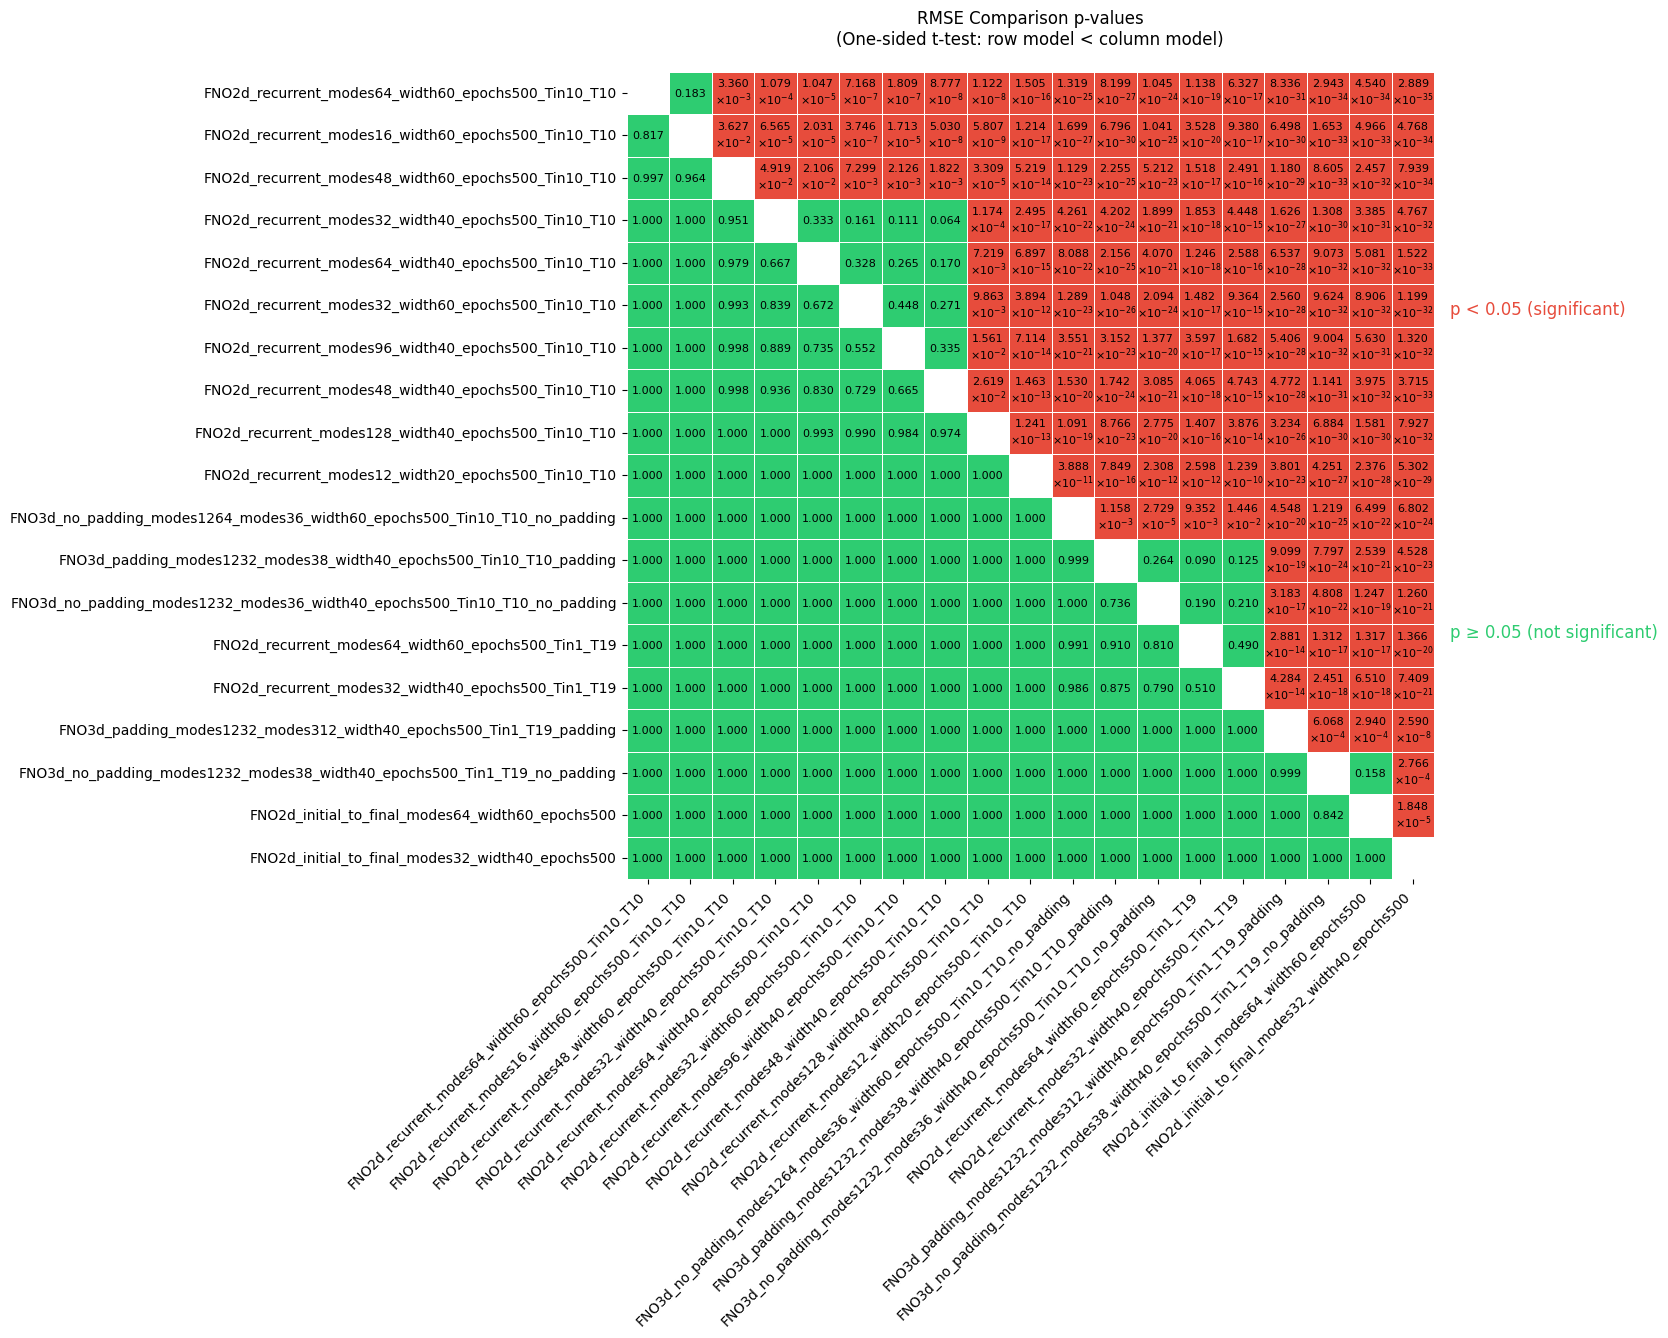


MAE p-value Heatmap (Row model better than column model)


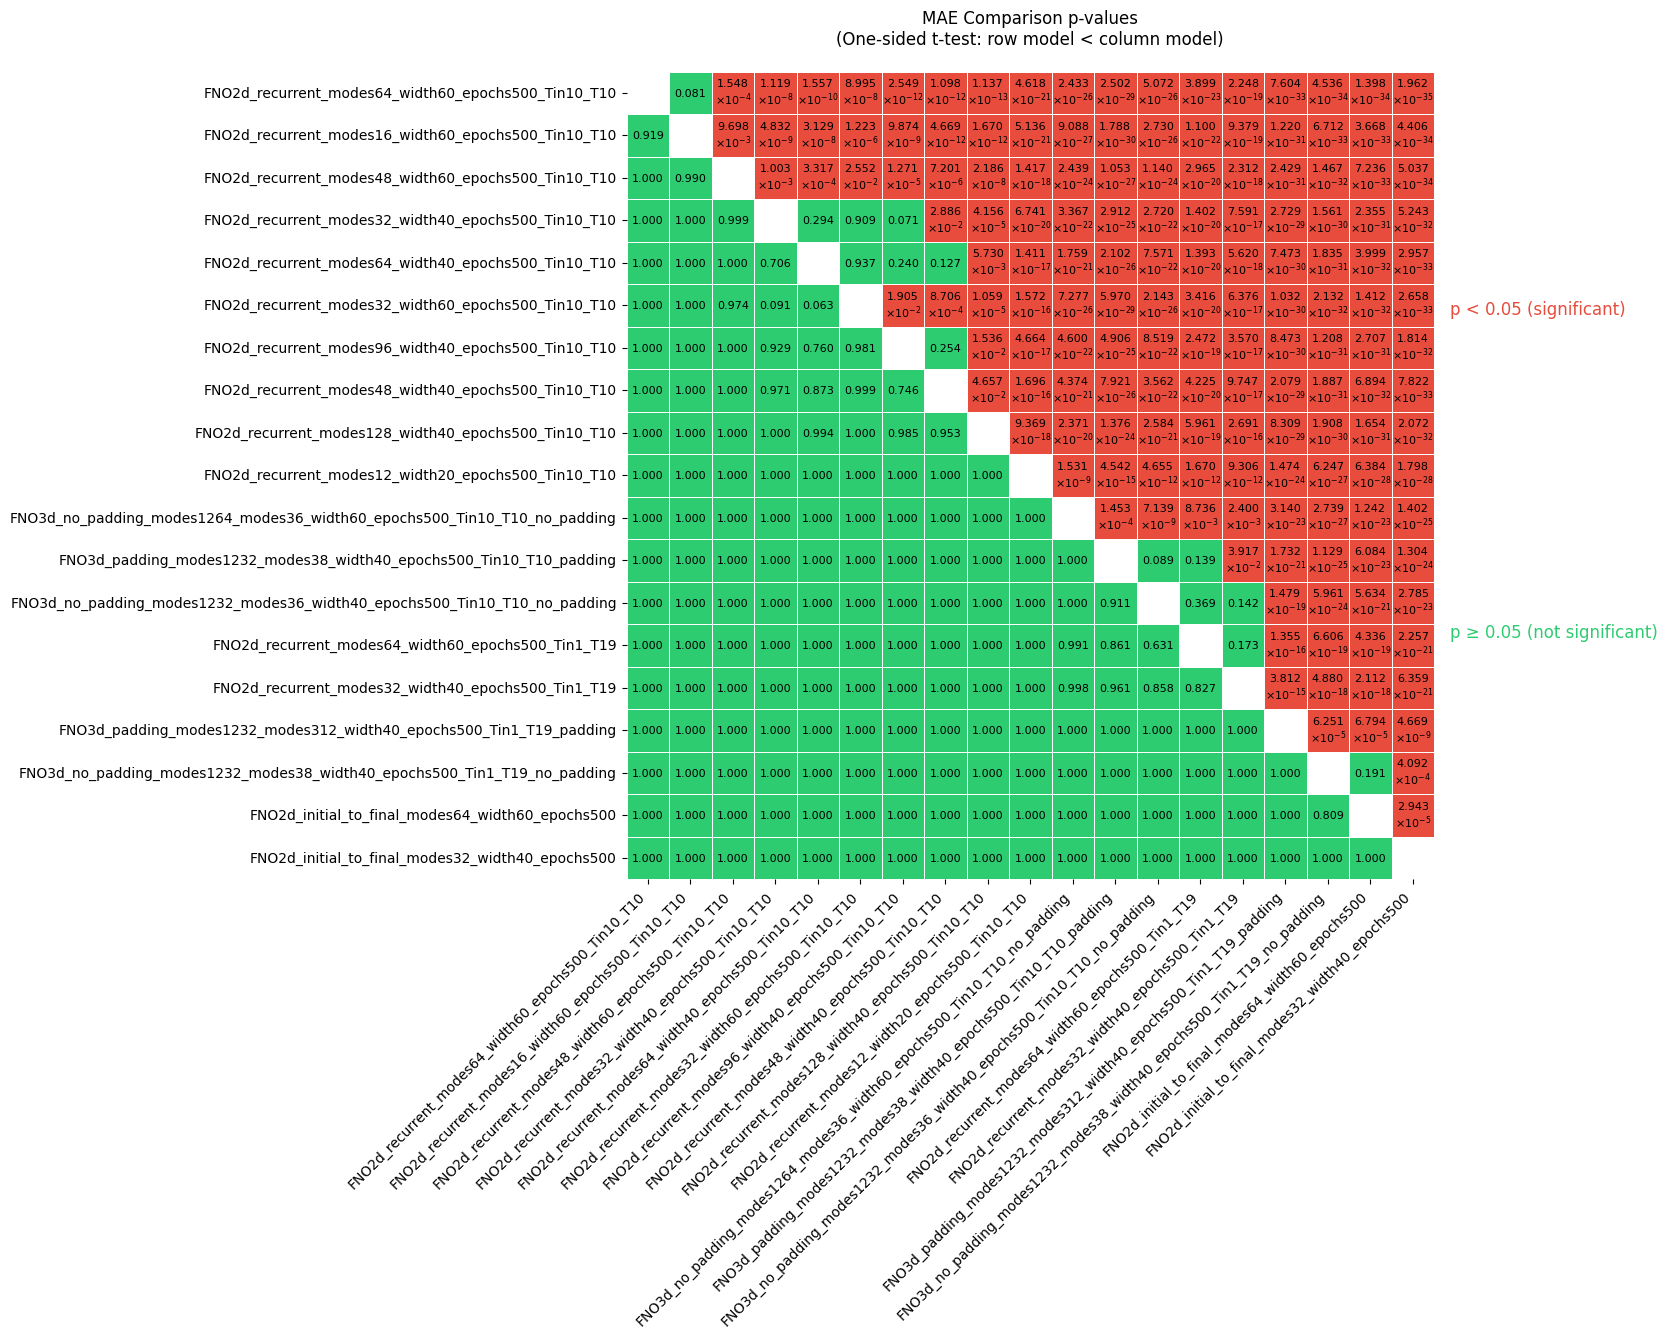

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import ListedColormap

# Prepare the square matrices
models = avg_perf_df['Model'].tolist()
n_models = len(models)

# Initialize p-value matrices
rmse_p_matrix = pd.DataFrame(np.full((n_models, n_models), np.nan), 
                            index=models, columns=models)
mae_p_matrix = pd.DataFrame(np.full((n_models, n_models), np.nan),
                           index=models, columns=models)

# Fill the matrices with p-values
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            continue
            
        model1 = models[i]
        model2 = models[j]
        
        # Get the data
        rmse1 = model_metrics[model1]['all_RMSE']
        rmse2 = model_metrics[model2]['all_RMSE']
        mae1 = model_metrics[model1]['all_MAE']
        mae2 = model_metrics[model2]['all_MAE']
        
        # Perform one-sided t-tests (model1 < model2)
        _, rmse_p = stats.ttest_rel(rmse1, rmse2, alternative='less')
        _, mae_p = stats.ttest_rel(mae1, mae2, alternative='less')
        
        # Store p-values
        rmse_p_matrix.iloc[i,j] = rmse_p
        mae_p_matrix.iloc[i,j] = mae_p

# Function to format p-values with 3 significant digits in two lines
def format_pvalue(p):
    if pd.isna(p):
        return ""
    if p == 0:
        return "0"
    if p >= 0.05:
        return f"{p:.3f}"
    
    # For significant p-values (<0.05), format as scientific notation with 3 digits
    exponent = np.floor(np.log10(p))
    coefficient = p / (10 ** exponent)
    return f"{coefficient:.3f}\n×10$^{{{int(exponent)}}}$"

# Create custom colormap (green for significant, red for non-significant)
cmap = ListedColormap(['#2ecc71', '#e74c3c'])  # Green and red

# Create heatmap visualization
def plot_pvalue_heatmap(p_matrix, title):
    plt.figure(figsize=(16, 15))
    
    # Create significance mask (True for significant p-values < 0.05)
    significance_mask = p_matrix < 0.05
    significance_mask = significance_mask.fillna(False)
    
    # Create mask for diagonal
    diagonal_mask = np.eye(len(p_matrix), dtype=bool)
    
    # Create combined mask
    mask = diagonal_mask
    
    # Create matrix for coloring (1=significant, 0=not significant)
    color_matrix = significance_mask.astype(int)
    
    # Plot heatmap
    ax = sns.heatmap(
        color_matrix,
        mask=mask,
        cmap=cmap,
        annot=np.vectorize(format_pvalue)(p_matrix.values),
        fmt="",
        cbar=False,
        square=True,
        linewidths=0.5,
        annot_kws={"size": 8, "color": "black"},
        vmin=0,
        vmax=1
    )
    
    # Add legend for color meaning
    ax.collections[0].colorbar = None
    plt.text(1.02, 0.7, "p < 0.05 (significant)", 
             transform=ax.transAxes, color='#e74c3c', fontsize=12)
    plt.text(1.02, 0.3, "p ≥ 0.05 (not significant)", 
             transform=ax.transAxes, color='#2ecc71', fontsize=12)
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.title(title, pad=20)
    plt.tight_layout()
    plt.show()

# Display the heatmaps
print("\nRMSE p-value Heatmap (Row model better than column model)")
plot_pvalue_heatmap(rmse_p_matrix, "RMSE Comparison p-values\n(One-sided t-test: row model < column model)")

print("\nMAE p-value Heatmap (Row model better than column model)")
plot_pvalue_heatmap(mae_p_matrix, "MAE Comparison p-values\n(One-sided t-test: row model < column model)")

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from matplotlib import cm

# Assuming avg_perf_df is your DataFrame
# Create a copy for styling
styled_df = avg_perf_df.copy()

# Define color maps for each column
# cmap_rmse = LinearSegmentedColormap.from_list('rmse_cmap', ['#2ecc71', '#e74c3c'])  # Green to red
# cmap_mae = LinearSegmentedColormap.from_list('mae_cmap', ['#3498db', '#9b59b6'])    # Blue to purple
cmap_rmse = cm.viridis
cmap_mae = cm.viridis
# cmap_mae = cm.plasma

# Normalize the data for coloring
norm_rmse = plt.Normalize(avg_perf_df['Avg RMSE'].min(), avg_perf_df['Avg RMSE'].max())
norm_mae = plt.Normalize(avg_perf_df['Avg MAE'].min(), avg_perf_df['Avg MAE'].max())

# Function to apply colors
def color_columns(val, col_name, cmap, norm):
    color = plt.cm.get_cmap(cmap)(norm(val))
    return f'background-color: rgba({color[0]*255:.0f}, {color[1]*255:.0f}, {color[2]*255:.0f}, {color[3]:.1f})'

# Apply styling
styled_df = styled_df.style\
    .apply(lambda x: [color_columns(v, 'Avg RMSE', cmap_rmse, norm_rmse) for v in x], subset=['Avg RMSE'])\
    .apply(lambda x: [color_columns(v, 'Avg MAE', cmap_mae, norm_mae) for v in x], subset=['Avg MAE'])\
    .format({'Avg RMSE': '{:.6f}', 'Avg MAE': '{:.6f}'})\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#34495e'), 
                 ('color', 'white'),
                 ('font-weight', 'bold')]
    }])

# Display the styled DataFrame
display(styled_df)

/tmp/ipykernel_565915/491465196.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmap)(norm(val))
/tmp/ipykernel_565915/491465196.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmap)(norm(val))


,Model,Avg RMSE,Avg MAE
5,FNO2d_recurrent_modes64_width60_epochs500_Tin10_T10,0.311532,0.213168
3,FNO2d_recurrent_modes32_width40_epochs500_Tin10_T10,0.335240,0.234046
8,FNO3d_no_padding_modes1264_modes36_width60_epochs500_Tin10_T10_no_padding,0.505344,0.347536
9,FNO3d_padding_modes1232_modes38_width40_epochs500_Tin10_T10_padding,0.527340,0.365085
6,FNO3d_no_padding_modes1232_modes36_width40_epochs500_Tin10_T10_no_padding,0.532029,0.371948
4,FNO2d_recurrent_modes64_width60_epochs500_Tin1_T19,0.548878,0.376137
2,FNO2d_recurrent_modes32_width40_epochs500_Tin1_T19,0.549336,0.387712
10,FNO3d_padding_modes1232_modes312_width40_epochs500_Tin1_T19_padding,0.764626,0.544359
7,FNO3d_no_padding_modes1232_modes38_width40_epochs500_Tin1_T19_no_padding,0.807495,0.580186
1,FNO2d_initial_to_final_modes64_width60_epochs500,0.825590,0.591958


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from matplotlib import cm
import re

# Assuming avg_perf_df is your original DataFrame
# First, let's create a function to parse the model names
def parse_model_name(model_name):
    # Initialize a dictionary to store parsed components
    components = {
        'model_type': None,  # 2d or 3d
        'architecture': None,  # recurrent, initial_to_final
        'modes1': None,
        'modes2': None,
        'modes3': None,
        'width': None,
        'epochs': None,
        'padding': None,  # padding or no_padding (for 3D models)
        'Tin': None,
        'Tout': None,
        # 'full_model_name': model_name  # Keep the original name in a new column
    }
    
    # Extract FNO dimension (2d or 3d)
    if 'FNO2d' in model_name:
        components['model_type'] = '2d'
    elif 'FNO3d' in model_name:
        components['model_type'] = '3d'
    
    # Extract architecture type
    if 'recurrent' in model_name:
        components['architecture'] = 'recurrent'
    elif 'initial_to_final' in model_name:
        components['architecture'] = 'initial_to_final'
    
    # Extract padding info for 3D models
    if 'no_padding' in model_name:
        components['padding'] = 'no'
    elif 'padding' in model_name:
        components['padding'] = 'yes'
    
    # Extract modes information
    if components['model_type'] == '2d':
        # For 2D models, modes parameter applies to both modes1 and modes2
        modes_match = re.search(r'modes(\d+)', model_name)
        if modes_match:
            mode_val = int(modes_match.group(1))
            components['modes1'] = mode_val
            components['modes2'] = mode_val
    elif components['model_type'] == '3d':
        # For 3D models, we have modes12 and modes3
        modes12_match = re.search(r'modes12(\d+)', model_name)
        modes3_match = re.search(r'modes3(\d+)', model_name)
        
        if modes12_match:
            mode_val = int(modes12_match.group(1))
            components['modes1'] = mode_val
            components['modes2'] = mode_val
        if modes3_match:
            components['modes3'] = int(modes3_match.group(1))
    
    # Extract width
    width_match = re.search(r'width(\d+)', model_name)
    if width_match:
        components['width'] = int(width_match.group(1))
    
    # Extract epochs
    epochs_match = re.search(r'epochs(\d+)', model_name)
    if epochs_match:
        components['epochs'] = int(epochs_match.group(1))
    
    # Extract Tin and Tout as integers
    tin_match = re.search(r'Tin(\d+)', model_name)
    if tin_match:
        components['Tin'] = int(tin_match.group(1))
    
    tout_match = re.search(r'_T(\d+)', model_name)  # Added underscore to avoid matching Tin
    if tout_match:
        components['Tout'] = int(tout_match.group(1))
    
    return components

# Create a copy of the original DataFrame
styled_df = avg_perf_df.copy()

# Parse model names and add new columns
parsed_data = styled_df['Model'].apply(parse_model_name).apply(pd.Series)
styled_df = pd.concat([styled_df, parsed_data], axis=1)

# For 2D models, ensure modes1 and modes2 are always the same
styled_df.loc[styled_df['model_type'] == '2d', 'modes2'] = styled_df.loc[styled_df['model_type'] == '2d', 'modes1']

# Replace None/NaN with empty strings
styled_df = styled_df.fillna('')

# Convert numeric columns to proper types (after filling NaN)
numeric_cols = ['modes1', 'modes2', 'modes3', 'width', 'epochs', 'Tin', 'Tout']
for col in numeric_cols:
    styled_df[col] = pd.to_numeric(styled_df[col], errors='ignore')

# Change Model column to just "FNO"
styled_df['Model'] = 'FNO'

# Reorder columns for better readability
column_order = [
    'Model', 'model_type', 'architecture', 'padding',
    'modes1', 'modes2', 'modes3', 'width', 'epochs',
    'Tin', 'Tout', 
     # 'full_model_name', 
    'Avg RMSE', 'Avg MAE'
]
styled_df = styled_df[column_order]

# Now apply the styling as before
# Define color maps for each column
cmap_rmse = cm.viridis
cmap_mae = cm.viridis

# Normalize the data for coloring
norm_rmse = plt.Normalize(styled_df['Avg RMSE'].min(), styled_df['Avg RMSE'].max())
norm_mae = plt.Normalize(styled_df['Avg MAE'].min(), styled_df['Avg MAE'].max())

# Function to apply colors
def color_columns(val, col_name, cmap, norm):
    if val == '':
        return ''
    color = plt.cm.get_cmap(cmap)(norm(val))
    return f'background-color: rgba({color[0]*255:.0f}, {color[1]*255:.0f}, {color[2]*255:.0f}, {color[3]:.1f})'

# Custom formatter function
def format_cell(x):
    if isinstance(x, (int, float)) and not pd.isna(x):
        if x == int(x):
            return f'{int(x)}'
        else:
            return f'{x:.6f}'
    else:
        return ''

# Apply styling
styled_df_style = styled_df.style\
    .apply(lambda x: [color_columns(v, 'Avg RMSE', cmap_rmse, norm_rmse) for v in x], subset=['Avg RMSE'])\
    .apply(lambda x: [color_columns(v, 'Avg MAE', cmap_mae, norm_mae) for v in x], subset=['Avg MAE'])\
    .format({
        'Avg RMSE': '{:.6f}', 
        'Avg MAE': '{:.6f}',
        'modes1': format_cell,
        'modes2': format_cell,
        'modes3': format_cell,
        'width': format_cell,
        'epochs': format_cell,
        'Tin': format_cell,
        'Tout': format_cell
    })\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#34495e'), 
                 ('color', 'white'),
                 ('font-weight', 'bold')]
    }])

# Display the styled DataFrame
display(styled_df_style)

/tmp/ipykernel_565915/2311905802.py:102: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  styled_df[col] = pd.to_numeric(styled_df[col], errors='ignore')
/tmp/ipykernel_565915/2311905802.py:130: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmap)(norm(val))
/tmp/ipykernel_565915/2311905802.py:130: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmap)(norm(val))


,Model,model_type,architecture,padding,modes1,modes2,modes3,width,epochs,Tin,Tout,Avg RMSE,Avg MAE
10,FNO,2d,recurrent,,64,64,,60,500,10,10,0.311532,0.213168
3,FNO,2d,recurrent,,16,16,,60,500,10,10,0.315702,0.216745
8,FNO,2d,recurrent,,48,48,,60,500,10,10,0.325217,0.223623
5,FNO,2d,recurrent,,32,32,,40,500,10,10,0.335240,0.234046
11,FNO,2d,recurrent,,64,64,,40,500,10,10,0.337644,0.235757
6,FNO,2d,recurrent,,32,32,,60,500,10,10,0.340296,0.230033
12,FNO,2d,recurrent,,96,96,,40,500,10,10,0.341112,0.237695
7,FNO,2d,recurrent,,48,48,,40,500,10,10,0.343496,0.239848
13,FNO,2d,recurrent,,128,128,,40,500,10,10,0.352749,0.244336
2,FNO,2d,recurrent,,12,12,,20,500,10,10,0.405792,0.287911
